In [ ]:
!pip install -q yfinance

In [ ]:
import yfinance as yf

df = yf.download(
    "GC=F",
    start="2000-01-01",
    end="2026-08-06",
    interval="1d"
)

df.columns = df.columns.droplevel(1)
df.columns.name = None

df.shape

/tmp/ipykernel_2642/2709396958.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


(6506, 5)

In [ ]:
# تحويل سعر الأونصة إلى سعر الجرام (عيار 24)
df["24K"] = df["Close"] / 31.1035

# حساب بقية العيارات
df["22K"] = df["24K"] * (22/24)
df["21K"] = df["24K"] * (21/24)
df["18K"] = df["24K"] * (18/24)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = df.dropna(subset=["Close"]).copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()
print(df.shape)
df[["Close","24K","22K","21K","18K"]].tail()

(6506, 9)


,Close,24K,22K,21K,18K
Date,,,,,
2026-07-30,4100.100098,131.821181,120.836082,115.343533,98.865886
2026-07-31,4049.100098,130.181494,119.333036,113.908807,97.636120
2026-08-03,4033.699951,129.686368,118.879171,113.475572,97.264776
2026-08-04,4095.399902,131.670066,120.697561,115.211308,98.752550
2026-08-05,4317.700195,138.817181,127.249083,121.465034,104.112886


 Feature Engineering

In [ ]:
HORIZON = 21  # trading month ahead (21 trading days

def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_features(data):
    #turns a raw price dataframe (must contain a '24K' column) into model-ready tabular features
    d = data.copy()
    for lag in [1, 2, 3, 5, 10, 20]:
        d[f"lag{lag}"] = d["24K"].shift(lag)
    d["ma7"]  = d["24K"].rolling(7).mean()
    d["ma14"] = d["24K"].rolling(14).mean()
    d["ma30"] = d["24K"].rolling(30).mean()
    d["std7"]  = d["24K"].rolling(7).std()
    d["std14"] = d["24K"].rolling(14).std()
    d["momentum5"]  = d["24K"] - d["lag5"]
    d["momentum10"] = d["24K"] - d["lag10"]
    d["rsi14"] = compute_rsi(d["24K"], 14)
    dow = d.index.dayofweek
    d["dow_sin"] = np.sin(2*np.pi*dow/7)
    d["dow_cos"] = np.cos(2*np.pi*dow/7)
    month = d.index.month
    d["month_sin"] = np.sin(2*np.pi*month/12)
    d["month_cos"] = np.cos(2*np.pi*month/12)
    return d

FEATURE_COLS = ["24K","lag1","lag2","lag3","lag5","lag10","lag20",
                "ma7","ma14","ma30","std7","std14","momentum5","momentum10",
                "rsi14","dow_sin","dow_cos","month_sin","month_cos"]
                  #lag = previous prices. to help the model learn recent trends
                  #ma = moving averages. it shows the trend
                  #rsi = Relative Strength Index to tell whether gold has recently been bought heavily or sold heavily

feat_df = build_features(df)
feat_df["target_24K"] = feat_df["24K"].shift(-HORIZON) # target = gold price after 21 trading days
feat_df = feat_df.dropna(subset=FEATURE_COLS + ["target_24K"])
print("Usable rows after feature engineering:", feat_df.shape)
feat_df[FEATURE_COLS + ["target_24K"]].tail()

Usable rows after feature engineering: (6456, 28)


,24K,lag1,lag2,lag3,lag5,lag10,lag20,ma7,ma14,ma30,std7,std14,momentum5,momentum10,rsi14,dow_sin,dow_cos,month_sin,month_cos,target_24K
Date,,,,,,,,,,,,,,,,,,,,
2026-06-30,129.339139,129.319853,131.133151,129.583487,132.779266,139.148327,143.880920,130.699576,133.452827,138.870009,2.213151,4.005873,-3.440127,-9.809189,37.551178,0.781831,0.623490,1.224647e-16,-1.000000,131.821181
2026-07-01,130.798786,129.339139,129.319853,131.133151,128.291030,139.241561,144.327812,130.177816,133.361197,138.351096,1.495464,4.054033,2.507756,-8.442775,47.641556,0.974928,-0.222521,-5.000000e-01,-0.866025,130.181494
2026-07-02,132.226283,130.798786,129.339139,129.319853,129.583487,140.141782,142.643117,130.098818,133.412638,137.929279,1.341856,4.033199,2.642796,-7.915498,51.283824,0.433884,-0.900969,-5.000000e-01,-0.866025,129.686368
2026-07-06,133.589471,132.226283,130.798786,129.339139,131.133151,135.807870,143.900198,130.855739,133.275079,137.526109,1.618102,3.988562,2.456320,-2.218400,46.209345,0.000000,1.000000,-5.000000e-01,-0.866025,131.670066
2026-07-07,133.274384,133.589471,132.226283,130.798786,129.319853,134.451104,139.440902,131.383009,132.855512,137.103327,1.731793,3.614635,3.954531,-1.176720,36.701105,0.781831,0.623490,-5.000000e-01,-0.866025,138.817181


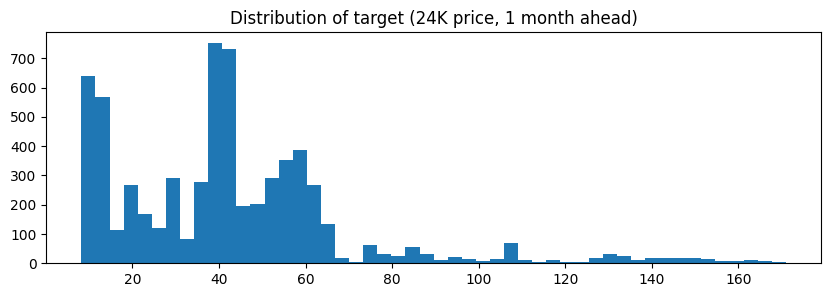

Skew: 1.6365318473108363


In [ ]:
# Target distribution check (skew)
plt.figure(figsize=(10,3))
plt.hist(feat_df["target_24K"], bins=50)
plt.title("Distribution of target (24K price, 1 month ahead)")
plt.show()
print("Skew:", feat_df["target_24K"].skew())

Train / Validation / Test (time-based, 70/15/15)

In [ ]:
X = feat_df[FEATURE_COLS].values
y = feat_df["target_24K"].values
dates = feat_df.index

n = len(feat_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
dates_test = dates[val_end:]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (4519, 19)  Val: (968, 19)  Test: (969, 19)


Scaling
scale X and y with StandardScaler, fitting only on the train set

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler().fit(X_train)
X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))
y_train_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

Baselines
- reference points: a naive random walk baseline ("price in a month = price today") and linear regressin baseline on the same features

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Naive baseline: assume no change over the horizon
naive_pred = X_test[:, 0]  # column 0 = current 24K price

# Linear regression baseline
lin_reg = LinearRegression().fit(X_train_s, y_train_s)
lin_pred = scaler_y.inverse_transform(lin_reg.predict(X_test_s).reshape(-1, 1)).ravel()

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label:30s} MAE={mae:7.3f}  RMSE={rmse:7.3f}  MAPE={mape:5.2f}%  R2={r2:6.4f}")
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)

baseline_results = {}
baseline_results["naive"] = evaluate(y_test, naive_pred, "Naive (no-change) baseline")
baseline_results["linreg"] = evaluate(y_test, lin_pred, "Linear Regression baseline")

Naive (no-change) baseline     MAE=  4.008  RMSE=  5.906  MAPE= 3.98%  R2=0.9663
Linear Regression baseline     MAE=  4.485  RMSE=  6.407  MAPE= 4.42%  R2=0.9604


 ANN Architecture (with regularization)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

def build_model(n_features, units1=128, units2=64, units3=32,
                 dropout1=0.3, dropout2=0.2, l2reg=1e-3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(units1, activation="relu", kernel_regularizer=regularizers.l2(l2reg)),
        layers.Dropout(dropout1),
        layers.Dense(units2, activation="relu", kernel_regularizer=regularizers.l2(l2reg)),
        layers.Dropout(dropout2),
        layers.Dense(units3, activation="relu"),
        layers.Dense(1, activation="linear"),   # linear output -> regression
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mae",              # more robust to outliers than MSE
        metrics=["mae", "mse"],
    )
    return model

build_model(X_train_s.shape[1]).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

Hyperparameter Tuning (manual search)
trying architecture/regularization/learning-rate combinations, each trained with early stopping, and keep the config with the best validation MAE


In [ ]:
configs = [
    dict(units1=64,  units2=32,  units3=16, dropout1=0.2, dropout2=0.1, l2reg=1e-4, lr=1e-3),
    dict(units1=128, units2=64,  units3=32, dropout1=0.3, dropout2=0.2, l2reg=1e-3, lr=1e-3),
    dict(units1=128, units2=64,  units3=32, dropout1=0.4, dropout2=0.3, l2reg=1e-3, lr=5e-4),
    dict(units1=256, units2=128, units3=64, dropout1=0.4, dropout2=0.3, l2reg=1e-2, lr=1e-3),
]

tuning_results = []
for i, cfg in enumerate(configs):
    tf.keras.backend.clear_session()
    model = build_model(X_train_s.shape[1], **cfg)
    es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = model.fit(X_train_s, y_train_s, validation_data=(X_val_s, y_val_s),
                      epochs=80, batch_size=32, callbacks=[es], verbose=0)
    best_val_mae = min(hist.history["val_mae"])
    tuning_results.append({"config": cfg, "val_mae_scaled": best_val_mae})
    print(f"Config {i}: {cfg} -> val_mae(scaled)={best_val_mae:.4f}")

best_cfg = min(tuning_results, key=lambda r: r["val_mae_scaled"])["config"]
print("\nBest config:", best_cfg)

Config 0: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001} -> val_mae(scaled)=0.2190
Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001} -> val_mae(scaled)=0.2468
Config 2: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.001, 'lr': 0.0005} -> val_mae(scaled)=0.2764
Config 3: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001} -> val_mae(scaled)=0.1381

Best config: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001}


Train final model with full callback stack
`EarlyStopping` + `ModelCheckpoint` + `ReduceLROnPlateau`, as recommended by the workflow

In [ ]:
tf.keras.backend.clear_session()
final_model = build_model(X_train_s.shape[1], **best_cfg)

cb_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    callbacks.ModelCheckpoint("best_gold_model.keras", monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6),
]

history = final_model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=300, batch_size=32,
    callbacks=cb_list, verbose=1,
)

Epoch 1/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3402 - mae: 0.2132 - mse: 0.0888 - val_loss: 0.7942 - val_mae: 0.2703 - val_mse: 0.0960 - learning_rate: 0.0010
Epoch 2/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4623 - mae: 0.1462 - mse: 0.0362 - val_loss: 0.5328 - val_mae: 0.3525 - val_mse: 0.1506 - learning_rate: 0.0010
Epoch 3/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2640 - mae: 0.1397 - mse: 0.0326 - val_loss: 0.3366 - val_mae: 0.2533 - val_mse: 0.0872 - learning_rate: 0.0010
Epoch 4/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1906 - mae: 0.1273 - mse: 0.0278 - val_loss: 0.2719 - val_mae: 0.2240 - val_mse: 0.0716 - learning_rate: 0.0010
Epoch 5/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1602 - mae: 0.1202 - mse: 0.0253 - val_loss: 0.2784 - val_mae: 0.2452 - val_mse: 0.0832 - learning_rate: 0.0010
Epoch 6/300
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1500 - mae: 0.1208 - mse: 0.0261 - val_loss: 0.2145 - val_mae:

Evaluate
Plot train vs. val loss check for overfitting or underfitting


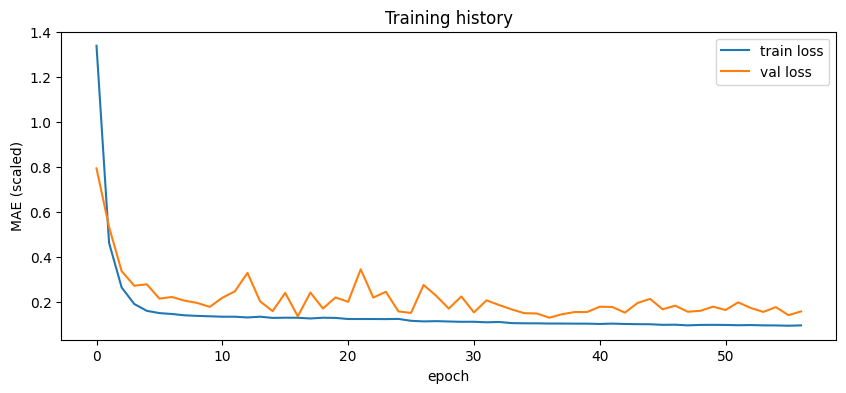

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("MAE (scaled)"); plt.legend()
plt.title("Training history")
plt.show()

--- Test set comparison ---
Naive baseline                 MAE=  4.008  RMSE=  5.906  MAPE= 3.98%  R2=0.9663
Linear Regression baseline     MAE=  4.485  RMSE=  6.407  MAPE= 4.42%  R2=0.9604
ANN (final model)              MAE=  4.967  RMSE=  6.951  MAPE= 4.99%  R2=0.9534


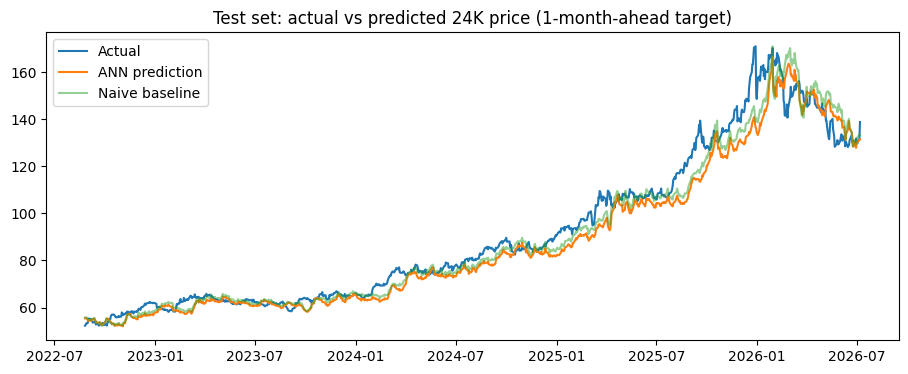

In [ ]:
y_test_pred_s = final_model.predict(X_test_s, verbose=0).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_s.reshape(-1, 1)).ravel()

print("Test set comparison ---")
evaluate(y_test, naive_pred, "Naive baseline")
evaluate(y_test, lin_pred, "Linear Regression baseline")
ann_metrics = evaluate(y_test, y_test_pred, "ANN (final model)")

plt.figure(figsize=(11,4))
plt.plot(dates_test, y_test, label="Actual")
plt.plot(dates_test, y_test_pred, label="ANN prediction")
plt.plot(dates_test, naive_pred, label="Naive baseline", alpha=0.5)
plt.legend(); plt.title("Test set: actual vs predicted 24K price (1-month-ahead target)")
plt.show()

## Predict next month + Karat conversion + Buy/sell signal
Building features from the most recent data (no target available yet, that's what we're forecasting) and generate the 1-month-ahead call

In [ ]:
latest_features = build_features(df)
latest_row = latest_features[FEATURE_COLS].iloc[[-1]].values
latest_row_s = scaler_X.transform(latest_row)

pred_s = final_model.predict(latest_row_s, verbose=0).ravel()[0]
pred_24K = scaler_y.inverse_transform([[pred_s]])[0][0]

current_24K = df["24K"].iloc[-1]
pct_change = (pred_24K - current_24K) / current_24K * 100

karat_forecast = {
    "24K": pred_24K,
    "21K": pred_24K * 21/24,
    "18K": pred_24K * 18/24,
}

BUY_THRESHOLD, SELL_THRESHOLD = 2.0, -2.0   # % move considered "meaningful"
if pct_change > BUY_THRESHOLD:
    signal = "BUY NOW / SELL LATER — price expected to rise"
elif pct_change < SELL_THRESHOLD:
    signal = "WAIT TO BUY / SELL NOW — price expected to fall"
else:
    signal = "HOLD — no strong trend expected"

print(f"Current 24K price/gram: {current_24K:.2f}")
print(f"Predicted price/gram in ~1 month:")
for k, v in karat_forecast.items():
    print(f"  {k}: {v:.2f}")
print(f"\nExpected change: {pct_change:+.2f}%")
print(f"Signal: {signal}")
print("\n(Educational project — not financial advice.)")

Current 24K price/gram: 138.82
Predicted price/gram in ~1 month:
  24K: 133.44
  21K: 116.76
  18K: 100.08

Expected change: -3.87%
Signal: WAIT TO BUY / SELL NOW — price expected to fall

(Educational project — not financial advice.)
